In [2]:
# INTRO

import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.db import get_connection

con = get_connection(read_only=True)

# Payer filing windows (days from date of service)
FILING_WINDOWS = {
    'medi_cal_managed_care':   90,
    'commercial_ppo':          180,
    'medicare_advantage':      365,
    'dual_eligible_cobpayer':  90,
}

print("Connection established.")
print("Tables:", [r[0] for r in con.execute("SHOW TABLES").fetchall()])


Connection established.
Tables: ['appeal_outcomes', 'claim_header', 'claim_line', 'denial_forensics', 'encounter_context', 'member_eligibility', 'provider', 'remittance_835']


------
#### Chapter 1 -- Charge Entry Lag Profile
###### Question: Who is capturing charges late, and how late?
###### Internal medicine's slow charge capture persona (mean lag: 14 days) is the hypothesis. This section confirms it and checks whether any other provider is quietly approaching their filing window.

In [2]:
lag_stats = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        COUNT(ch.claim_id)                                                          AS claim_count,
        ROUND(AVG(date_diff('day', ch.date_of_service, ch.submission_date)), 1)     AS avg_lag_days,
        ROUND(MEDIAN(date_diff('day', ch.date_of_service, ch.submission_date)), 1)  AS median_lag_days,
        MAX(date_diff('day', ch.date_of_service, ch.submission_date))               AS max_lag_days,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (
            ORDER BY date_diff('day', ch.date_of_service, ch.submission_date)
        ), 0)                                                                        AS p95_lag_days
    FROM claim_header ch
    JOIN provider p ON ch.provider_id = p.provider_id
    WHERE ch.date_of_service IS NOT NULL
      AND ch.submission_date IS NOT NULL
    GROUP BY p.practice_name, p.persona_type
    ORDER BY avg_lag_days DESC
""").df()

print("Charge Entry Lag — by Provider Persona\n")
print(lag_stats.to_string(index=False))


Charge Entry Lag — by Provider Persona

          practice_name              persona_type  claim_count  avg_lag_days  median_lag_days  max_lag_days  p95_lag_days
Internal Medicine Group       slow_charge_capture         5129          19.1             14.0           109          96.0
Behavioral Health Group      credentialing_errors         4987           6.5              6.0            18          11.0
         Oncology Group medical_necessity_denials         4928           4.5              5.0            11           8.0
        Emergency Group             coding_errors         5020           4.5              4.0            11           8.0
        Radiology Group           prior_auth_miss         4936           2.5              2.0             6           4.0


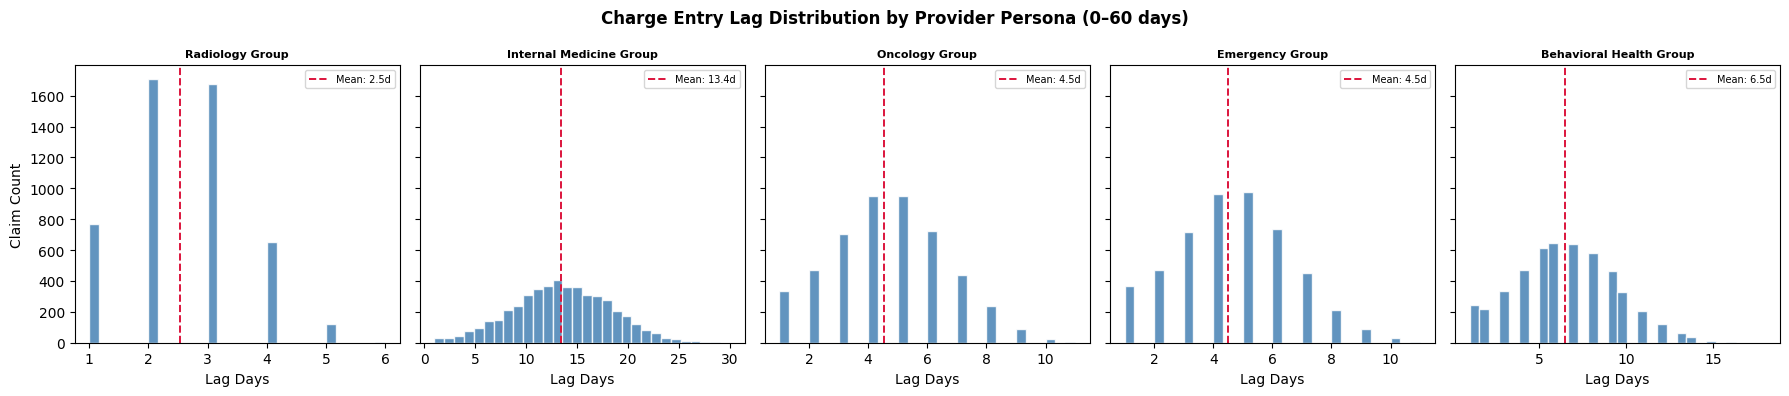

In [7]:
lag_raw = con.execute("""
    SELECT
        p.practice_name,
        date_diff('day', ch.date_of_service, ch.submission_date) AS lag_days
    FROM claim_header ch
    JOIN provider p ON ch.provider_id = p.provider_id
    WHERE ch.date_of_service IS NOT NULL
      AND ch.submission_date IS NOT NULL
      AND date_diff('day', ch.date_of_service, ch.submission_date) BETWEEN 0 AND 60
""").df()

providers = lag_raw["practice_name"].unique()
fig, axes = plt.subplots(1, len(providers), figsize=(18, 4), sharey=True)

for ax, prov in zip(axes, providers):
    subset = lag_raw[lag_raw["practice_name"] == prov]["lag_days"]
    ax.hist(subset, bins=30, edgecolor="white", color="steelblue", alpha=0.85)
    ax.axvline(subset.mean(), color="crimson", linestyle="--", linewidth=1.4,
               label=f"Mean: {subset.mean():.1f}d")
    ax.set_title(prov.replace("_", "\n"), fontsize=8, fontweight="bold")
    ax.set_xlabel("Lag Days")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Claim Count")
fig.suptitle("Charge Entry Lag Distribution by Provider Persona (0–60 days)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [4]:
lag_buckets = con.execute("""
    SELECT
        p.practice_name,
        COUNT(*) AS total_claims,
        SUM(CASE WHEN date_diff('day', ch.date_of_service, ch.submission_date) <= 7
                 THEN 1 ELSE 0 END) AS within_7d,
        SUM(CASE WHEN date_diff('day', ch.date_of_service, ch.submission_date) BETWEEN 8 AND 14
                 THEN 1 ELSE 0 END) AS d8_14,
        SUM(CASE WHEN date_diff('day', ch.date_of_service, ch.submission_date) BETWEEN 15 AND 30
                 THEN 1 ELSE 0 END) AS d15_30,
        SUM(CASE WHEN date_diff('day', ch.date_of_service, ch.submission_date) > 30
                 THEN 1 ELSE 0 END) AS over_30d,
        ROUND(100.0 * SUM(CASE WHEN date_diff('day', ch.date_of_service, ch.submission_date) > 30
                               THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_over_30d
    FROM claim_header ch
    JOIN provider p ON ch.provider_id = p.provider_id
    WHERE ch.date_of_service IS NOT NULL
      AND ch.submission_date IS NOT NULL
    GROUP BY p.practice_name
    ORDER BY pct_over_30d DESC
""").df()

print("Charge Lag Buckets — % of claims by time band\n")
print(lag_buckets.to_string(index=False))


Charge Lag Buckets — % of claims by time band

          practice_name  total_claims  within_7d  d8_14  d15_30  over_30d  pct_over_30d
Internal Medicine Group          5129      568.0 2241.0  1988.0     332.0           6.5
        Radiology Group          4936     4936.0    0.0     0.0       0.0           0.0
Behavioral Health Group          4987     3173.0 1799.0    15.0       0.0           0.0
         Oncology Group          4928     4568.0  360.0     0.0       0.0           0.0
        Emergency Group          5020     4687.0  333.0     0.0       0.0           0.0


----
#### Chapter 2 · Timely Filing Root Cause Chain

###### Question: Where is charge lag colliding with a short payer filing window?
###### The formula: [ `filing_window - avg_lag = buffer`] — lower buffer = higher CO-29 risk.

###### Medi-Cal and Dual Eligible carry 90-day windows. An internal medicine claim averaging a high lag has very little buffer to spare.

In [8]:
filing_risk = con.execute("""
    SELECT
        p.practice_name,
        ch.payer_id,
        COUNT(*)                                                                          AS claim_count,
        ROUND(AVG(date_diff('day', ch.date_of_service, ch.submission_date)), 1)          AS avg_lag_days,
        CASE ch.payer_id
            WHEN 'medi_cal_managed_care'   THEN 90
            WHEN 'commercial_ppo'          THEN 180
            WHEN 'medicare_advantage'      THEN 365
            WHEN 'dual_eligible_cobpayer'  THEN 90
        END                                                                               AS filing_window_days,
        ROUND(
            CASE ch.payer_id
                WHEN 'medi_cal_managed_care'   THEN 90
                WHEN 'commercial_ppo'          THEN 180
                WHEN 'medicare_advantage'      THEN 365
                WHEN 'dual_eligible_cobpayer'  THEN 90
            END
            - AVG(date_diff('day', ch.date_of_service, ch.submission_date))
        , 1)                                                                              AS avg_buffer_days
    FROM claim_header ch
    JOIN provider p ON ch.provider_id = p.provider_id
    WHERE ch.date_of_service IS NOT NULL
      AND ch.submission_date IS NOT NULL
    GROUP BY p.practice_name, ch.payer_id
    ORDER BY p.practice_name, avg_buffer_days ASC
""").df()

print("Filing Window Buffer (filing_window - avg_lag days) — Lower = Higher CO-29 Risk\n")
print(filing_risk.to_string(index=False))

at_risk = filing_risk[filing_risk["avg_buffer_days"] < 30]
if not at_risk.empty:
    print("\n⚠ Combinations with <30-day average buffer:")
    print(at_risk[["practice_name", "payer_id", "avg_lag_days",
                    "filing_window_days", "avg_buffer_days"]].to_string(index=False))


Filing Window Buffer (filing_window - avg_lag days) — Lower = Higher CO-29 Risk

          practice_name               payer_id  claim_count  avg_lag_days  filing_window_days  avg_buffer_days
Behavioral Health Group dual_eligible_cobpayer          244           6.4                  90             83.6
Behavioral Health Group  medi_cal_managed_care         2219           6.4                  90             83.6
Behavioral Health Group         commercial_ppo         1524           6.4                 180            173.6
Behavioral Health Group     medicare_advantage         1000           6.7                 365            358.3
        Emergency Group  medi_cal_managed_care         2366           4.5                  90             85.5
        Emergency Group dual_eligible_cobpayer          243           4.5                  90             85.5
        Emergency Group         commercial_ppo         1422           4.5                 180            175.5
        Emergency Group     med

#### For this next matrix, we show the CO-29 results, which are when a payer's filing window is exceeded.
###### CO-29 (timely filing) fires only when `submission_date - date_of_service`
###### exceeds a payer's filing window. The matrix tests every provider × payer
###### combination simultaneously.
######
###### **Why only Internal Medicine Group shows non-zero values:**
###### Internal Medicine is the only provider with a charge capture lag tail
###### that can reach 90+ days (the slow_charge_capture persona, ~7% of claims).
######
###### Commercial PPO (180-day window) and Medicare Advantage (365-day window)
###### are never breached at that lag range. Only Medi-Cal and Dual Eligible
###### both 90-day windows) sit close enough to the lag distribution to collide.
###### The 0.0% cells are confirmatory — those combinations are not at risk.
###### The finding IS the story: timely filing risk is a specific provider × payer
##### collision, not a portfolio-wide problem.

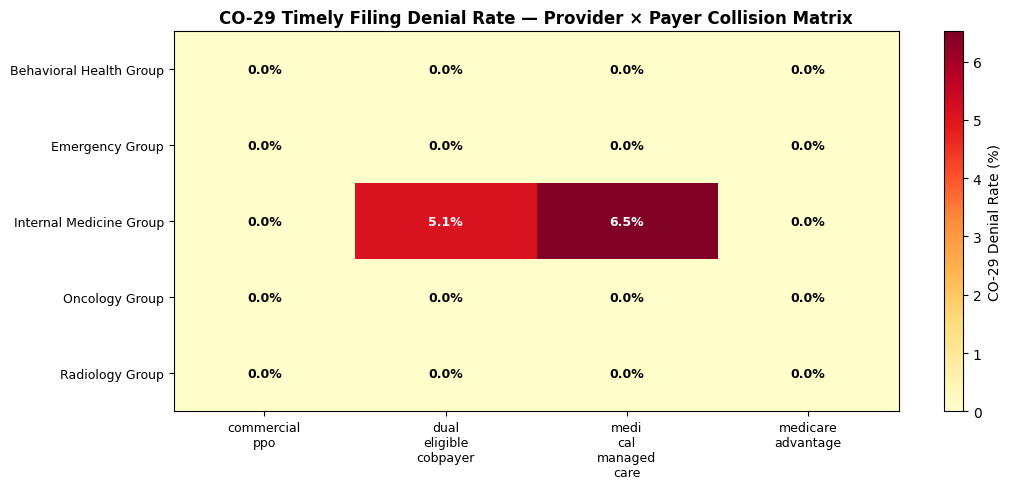


Top 10 CO-29 risk combinations:
          practice_name               payer_id  total_claims  co29_denials  co29_rate_pct
Internal Medicine Group  medi_cal_managed_care          2300           150           6.52
Internal Medicine Group dual_eligible_cobpayer           255            13           5.10
        Radiology Group  medi_cal_managed_care          2280             0           0.00
        Emergency Group         commercial_ppo          1422             0           0.00
        Radiology Group     medicare_advantage           988             0           0.00
Internal Medicine Group     medicare_advantage          1038             0           0.00
         Oncology Group     medicare_advantage           982             0           0.00
         Oncology Group  medi_cal_managed_care          2171             0           0.00
        Emergency Group dual_eligible_cobpayer           243             0           0.00
Behavioral Health Group     medicare_advantage          1000       

In [6]:
co29_matrix = con.execute("""
    WITH co29_claims AS (
        SELECT DISTINCT claim_id
        FROM remittance_835
        WHERE carc_code = 'CO-29'
    )
    SELECT
        p.practice_name,
        ch.payer_id,
        COUNT(DISTINCT ch.claim_id)                                                              AS total_claims,
        COUNT(DISTINCT c29.claim_id)                                                             AS co29_denials,
        ROUND(100.0 * COUNT(DISTINCT c29.claim_id) / NULLIF(COUNT(DISTINCT ch.claim_id), 0), 2) AS co29_rate_pct
    FROM claim_header ch
    JOIN provider p ON ch.provider_id = p.provider_id
    LEFT JOIN co29_claims c29 ON ch.claim_id = c29.claim_id
    GROUP BY p.practice_name, ch.payer_id
    ORDER BY co29_rate_pct DESC
""").df()

pivot = co29_matrix.pivot(
    index="practice_name", columns="payer_id", values="co29_rate_pct"
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c.replace("_", "\n") for c in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
vmax = pivot.values.max() if pivot.values.max() > 0 else 1
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val > vmax * 0.6 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)
plt.colorbar(im, ax=ax, label="CO-29 Denial Rate (%)")
ax.set_title("CO-29 Timely Filing Denial Rate — Provider × Payer Collision Matrix",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 10 CO-29 risk combinations:")
print(co29_matrix.head(10).to_string(index=False))

Timeliness CARC Codes — Denial Rate by Provider

          practice_name              persona_type carc_code  denial_claims  dollars_at_risk  denial_rate_pct
        Emergency Group             coding_errors     CO-16            655        916103.49            13.05
Behavioral Health Group      credentialing_errors     CO-16            272         40595.44             5.45
Internal Medicine Group       slow_charge_capture     CO-16            256         52313.77             4.99
         Oncology Group medical_necessity_denials     CO-16            125        606758.67             2.54
        Radiology Group           prior_auth_miss     CO-16             93         64971.78             1.88
Internal Medicine Group       slow_charge_capture     CO-22            113         23355.93             2.20
         Oncology Group medical_necessity_denials     CO-22            107        511642.37             2.17
        Emergency Group             coding_errors     CO-22             96     

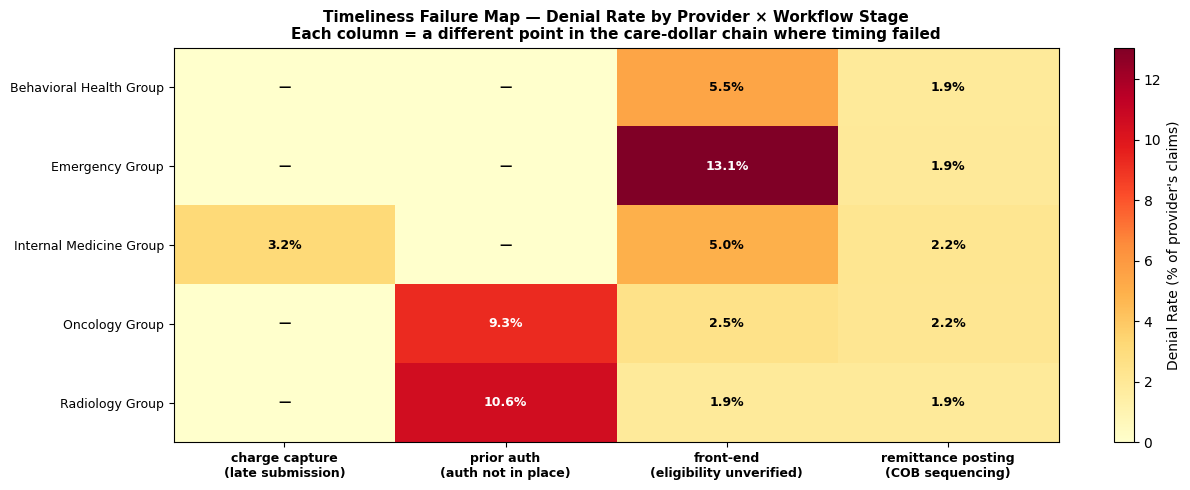


Timeliness Denial Dollar Impact

carc_code  denial_count  dollars_at_risk  avg_recovery_prob  expected_recoverable
    CO-57          1281       2986941.52               0.55            1642817.84
    CO-16          1591       1680743.15               0.72            1210135.07
    CO-22           595        765555.38               0.55             421055.46
    CO-29           448         80433.83               0.10               8043.38


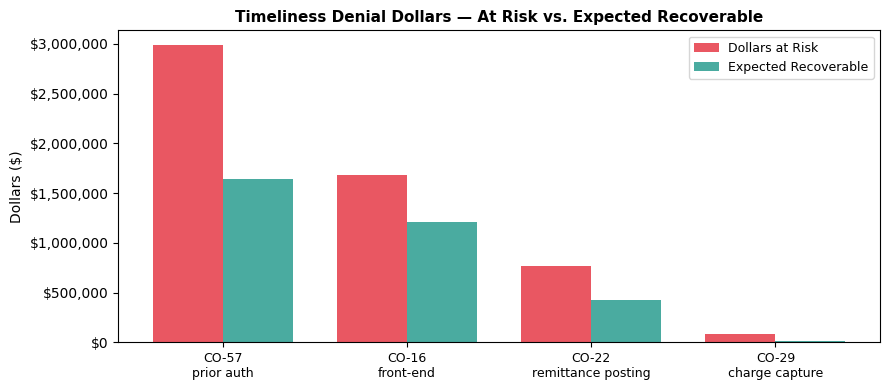


Key observation:
CO-29 has the lowest recovery probability (10%) — once the filing window closes,
the dollar is largely unrecoverable. Prevention is the only intervention.
CO-57 and CO-16 are both recoverable via corrected resubmission (48–72%).
CO-22 requires obtaining primary remittance first, then resubmitting secondary.


In [10]:
# Stage mapping:
#   CO-29 → charge_capture          (claim submitted too late)
#   CO-57 → prior_authorization     (auth not in place before service)
#   CO-16 → billing / front-end     (eligibility not verified before service)
#   CO-22 → remittance_posting      (COB sequencing — secondary too early)
# ============================================================

 
TIMELINESS_CARCS = ['CO-29', 'CO-57', 'CO-16', 'CO-22']
 
CARC_STAGE = {
    'CO-29': 'charge capture\n(late submission)',
    'CO-57': 'prior auth\n(auth not in place)',
    'CO-16': 'front-end\n(eligibility unverified)',
    'CO-22': 'remittance posting\n(COB sequencing)',
}
 
# ── Query: timeliness denial rate by provider × CARC ─────────────────────────
# Denominator = all claims for that provider (including paid)
# Numerator   = denials for each timeliness CARC code
# Gives true denial rate, not the circular 100% from filtering to denials first
 
timeliness_by_provider = con.execute("""
    WITH all_claims AS (
        SELECT ch.claim_id, ch.provider_id, COUNT(*) AS total_lines
        FROM claim_header ch
        JOIN remittance_835 r ON ch.claim_id = r.claim_id
        GROUP BY ch.claim_id, ch.provider_id
    ),
    timeliness_denials AS (
        SELECT
            ch.provider_id,
            df.carc_code,
            COUNT(DISTINCT ch.claim_id) AS denial_claims,
            ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
        FROM denial_forensics df
        JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
        JOIN claim_header ch  ON r.claim_id = ch.claim_id
        WHERE df.carc_code IN ('CO-29', 'CO-57', 'CO-16', 'CO-22')
        GROUP BY ch.provider_id, df.carc_code
    )
    SELECT
        p.practice_name,
        p.persona_type,
        td.carc_code,
        td.denial_claims,
        td.dollars_at_risk,
        ROUND(100.0 * td.denial_claims /
              NULLIF(COUNT(DISTINCT ac.claim_id), 0), 2) AS denial_rate_pct
    FROM timeliness_denials td
    JOIN provider p ON td.provider_id = p.provider_id
    JOIN all_claims ac ON td.provider_id = ac.provider_id
    GROUP BY p.practice_name, p.persona_type, td.carc_code,
             td.denial_claims, td.dollars_at_risk
    ORDER BY td.carc_code, denial_rate_pct DESC
""").df()
 
print("Timeliness CARC Codes — Denial Rate by Provider\n")
print(timeliness_by_provider.to_string(index=False))
 
# ── Heatmap: provider × timeliness CARC — denial rate ────────────────────────
pivot_rate = timeliness_by_provider.pivot_table(
    index="practice_name",
    columns="carc_code",
    values="denial_rate_pct",
    aggfunc="sum"
).fillna(0).reindex(columns=TIMELINESS_CARCS, fill_value=0)
 
# Rename columns to include stage context
pivot_rate.columns = [CARC_STAGE.get(c, c) for c in pivot_rate.columns]
 
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(pivot_rate.values, cmap="YlOrRd", aspect="auto")
 
ax.set_xticks(range(len(pivot_rate.columns)))
ax.set_xticklabels(pivot_rate.columns, fontsize=9, fontweight="bold")
ax.set_yticks(range(len(pivot_rate.index)))
ax.set_yticklabels(pivot_rate.index, fontsize=9)
 
vmax = pivot_rate.values.max() if pivot_rate.values.max() > 0 else 1
for i in range(len(pivot_rate.index)):
    for j in range(len(pivot_rate.columns)):
        val = pivot_rate.values[i, j]
        color = "white" if val > vmax * 0.55 else "black"
        label = f"{val:.1f}%" if val > 0 else "—"
        ax.text(j, i, label, ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)
 
plt.colorbar(im, ax=ax, label="Denial Rate (% of provider's claims)")
ax.set_title(
    "Timeliness Failure Map — Denial Rate by Provider × Workflow Stage\n"
    "Each column = a different point in the care-dollar chain where timing failed",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()
 
 
# ── Dollar impact: timeliness denials by CARC ─────────────────────────────────
timeliness_dollars = con.execute("""
    SELECT
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    WHERE df.carc_code IN ('CO-29', 'CO-57', 'CO-16', 'CO-22')
    GROUP BY df.carc_code
    ORDER BY dollars_at_risk DESC
""").df()
 
print("\nTimeliness Denial Dollar Impact\n")
print(timeliness_dollars.to_string(index=False))
 
# Bar chart: dollars at risk vs recoverable by timeliness CARC
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(timeliness_dollars))
width = 0.38
 
ax.bar(x - width/2, timeliness_dollars["dollars_at_risk"], width,
       label="Dollars at Risk", color="#e63946", alpha=0.85)
ax.bar(x + width/2, timeliness_dollars["expected_recoverable"], width,
       label="Expected Recoverable", color="#2a9d8f", alpha=0.85)
 
ax.set_xticks(x)
ax.set_xticklabels([
    f"{row['carc_code']}\n{CARC_STAGE.get(row['carc_code'], '').split(chr(10))[0]}"
    for _, row in timeliness_dollars.iterrows()
], fontsize=9)
ax.set_ylabel("Dollars ($)")
ax.set_title("Timeliness Denial Dollars — At Risk vs. Expected Recoverable",
             fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
 
print("\nKey observation:")
print("CO-29 has the lowest recovery probability (10%) — once the filing window closes,")
print("the dollar is largely unrecoverable. Prevention is the only intervention.")
print("CO-57 and CO-16 are both recoverable via corrected resubmission (48–72%).")
print("CO-22 requires obtaining primary remittance first, then resubmitting secondary.")

-------
#### Chapter 3 -- Adjudication Cycle Time

###### Question: How long from submission to adjudication — and does denial inflate the clock?

###### A slow payer creates AR aging drag on clean claims. A denied claim extends that drag through the rework cycle. Both erode cash flow — but for different operational reasons.

Adjudication Cycle Time by Payer

              payer_id  claim_count  avg_cycle_days  median_cycle_days  p90_cycle_days
dual_eligible_cobpayer         1232            55.6               56.0            61.0
 medi_cal_managed_care        11336            40.7               41.0            46.0
    medicare_advantage         4997            25.6               26.0            31.0
        commercial_ppo         7435            15.6               16.0            21.0


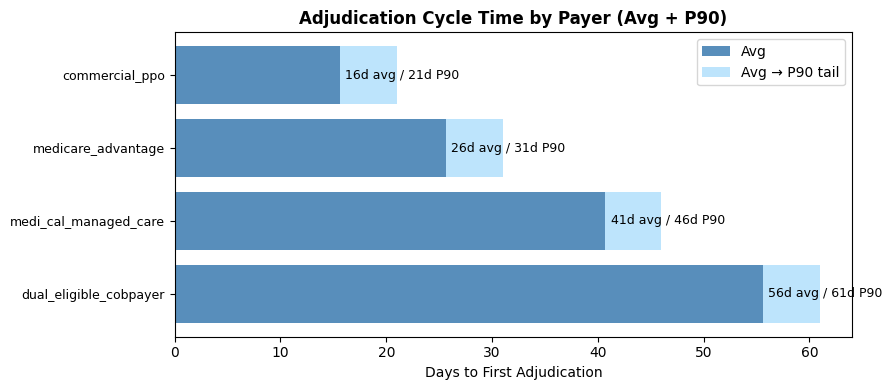

In [9]:
cycle_time = con.execute("""
    WITH claim_cycle AS (
        SELECT
            ch.claim_id,
            ch.payer_id,
            ch.submission_date,
            MIN(r.adjudication_date) AS first_adjudication_date
        FROM claim_header ch
        JOIN remittance_835 r ON ch.claim_id = r.claim_id
        WHERE ch.submission_date IS NOT NULL
          AND r.adjudication_date IS NOT NULL
        GROUP BY ch.claim_id, ch.payer_id, ch.submission_date
    )
    SELECT
        payer_id,
        COUNT(*)                                                                          AS claim_count,
        ROUND(AVG(date_diff('day', submission_date, first_adjudication_date)), 1)        AS avg_cycle_days,
        ROUND(MEDIAN(date_diff('day', submission_date, first_adjudication_date)), 1)     AS median_cycle_days,
        ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP (
            ORDER BY date_diff('day', submission_date, first_adjudication_date)
        ), 0)                                                                             AS p90_cycle_days
    FROM claim_cycle
    GROUP BY payer_id
    ORDER BY avg_cycle_days DESC
""").df()

print("Adjudication Cycle Time by Payer\n")
print(cycle_time.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(cycle_time))
ax.barh(list(y), cycle_time["avg_cycle_days"], color="steelblue", label="Avg", alpha=0.9)
ax.barh(list(y),
        cycle_time["p90_cycle_days"] - cycle_time["avg_cycle_days"],
        left=cycle_time["avg_cycle_days"],
        color="lightskyblue", alpha=0.55, label="Avg → P90 tail")
for i, (avg, p90) in enumerate(zip(cycle_time["avg_cycle_days"], cycle_time["p90_cycle_days"])):
    ax.text(avg + 0.5, i, f"{avg:.0f}d avg / {p90:.0f}d P90", va="center", fontsize=9)
ax.set_yticks(list(y))
ax.set_yticklabels(cycle_time["payer_id"], fontsize=9)
ax.set_xlabel("Days to First Adjudication")
ax.set_title("Adjudication Cycle Time by Payer (Avg + P90)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Full Cash Pipeline by Payer (Service → Adjudication)

              payer_id  claim_count  avg_charge_lag  avg_adjudication_days  total_pipeline_days  p90_pipeline_days
dual_eligible_cobpayer         1232             7.4                   55.6                 63.0               71.0
 medi_cal_managed_care        11336             7.5                   40.7                 48.1               56.0
    medicare_advantage         4997             7.7                   25.6                 33.3               41.0
        commercial_ppo         7435             7.5                   15.6                 23.1               31.0


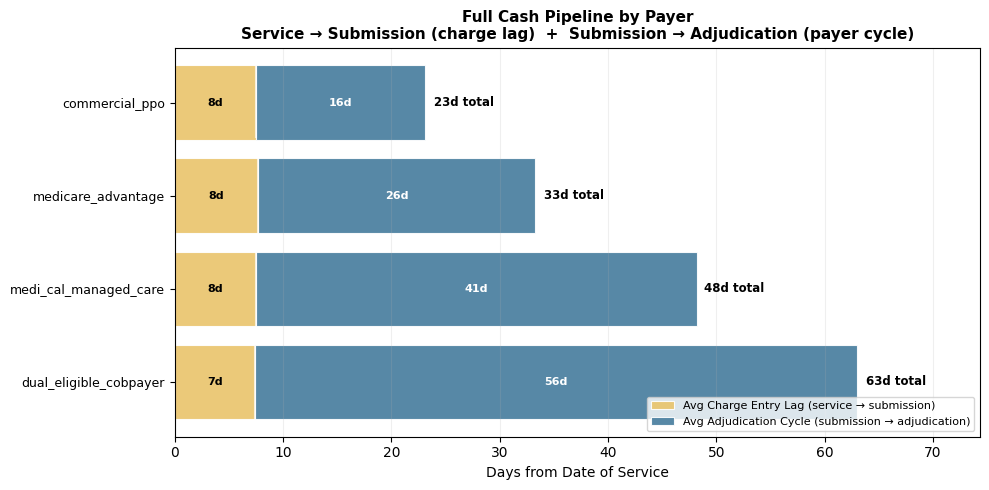


Key insight:
  dual_eligible_cobpayer          charge lag = 12% of pipeline  |  adjudication = 88% of pipeline  |  total = 63d
  medi_cal_managed_care           charge lag = 16% of pipeline  |  adjudication = 85% of pipeline  |  total = 48d
  medicare_advantage              charge lag = 23% of pipeline  |  adjudication = 77% of pipeline  |  total = 33d
  commercial_ppo                  charge lag = 32% of pipeline  |  adjudication = 68% of pipeline  |  total = 23d


In [9]:
full_pipeline = con.execute("""
    WITH claim_cycle AS (
        SELECT
            ch.claim_id,
            ch.payer_id,
            ch.date_of_service,
            ch.submission_date,
            MIN(r.adjudication_date) AS first_adjudication_date
        FROM claim_header ch
        JOIN remittance_835 r ON ch.claim_id = r.claim_id
        WHERE ch.submission_date IS NOT NULL
          AND ch.date_of_service IS NOT NULL
          AND r.adjudication_date IS NOT NULL
        GROUP BY ch.claim_id, ch.payer_id, ch.date_of_service, ch.submission_date
    )
    SELECT
        payer_id,
        COUNT(*)                                                                       AS claim_count,
        ROUND(AVG(date_diff('day', date_of_service, submission_date)), 1)             AS avg_charge_lag,
        ROUND(AVG(date_diff('day', submission_date, first_adjudication_date)), 1)     AS avg_adjudication_days,
        ROUND(AVG(date_diff('day', date_of_service, first_adjudication_date)), 1)     AS total_pipeline_days,
        ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP (
            ORDER BY date_diff('day', date_of_service, first_adjudication_date)
        ), 0)                                                                          AS p90_pipeline_days
    FROM claim_cycle
    GROUP BY payer_id
    ORDER BY total_pipeline_days DESC
""").df()
 
print("Full Cash Pipeline by Payer (Service → Adjudication)\n")
print(full_pipeline.to_string(index=False))
 
# Stacked bar: charge lag + adjudication cycle = total pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
 
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(full_pipeline))
 
# Segment 1: Charge entry lag (service → submission)
bars1 = ax.barh(
    list(y),
    full_pipeline["avg_charge_lag"],
    color="#e9c46a",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    label="Avg Charge Entry Lag (service → submission)"
)
 
# Segment 2: Adjudication cycle (submission → adjudication)
bars2 = ax.barh(
    list(y),
    full_pipeline["avg_adjudication_days"],
    left=full_pipeline["avg_charge_lag"],
    color="#457b9d",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    label="Avg Adjudication Cycle (submission → adjudication)"
)
 
# Label: submission divider + total
for i, (lag, adj, total) in enumerate(zip(
    full_pipeline["avg_charge_lag"],
    full_pipeline["avg_adjudication_days"],
    full_pipeline["total_pipeline_days"]
)):
    # Mark the submission point
    ax.axvline(x=lag, ymin=(i / len(y)) + 0.02,
               ymax=((i + 1) / len(y)) - 0.02,
               color="white", linewidth=1.5, alpha=0.7)
    # Label inside charge lag segment
    if lag > 5:
        ax.text(lag / 2, i, f"{lag:.0f}d",
                ha="center", va="center", fontsize=8,
                color="black", fontweight="bold")
    # Label inside adjudication segment
    if adj > 5:
        ax.text(lag + adj / 2, i, f"{adj:.0f}d",
                ha="center", va="center", fontsize=8,
                color="white", fontweight="bold")
    # Total at end
    ax.text(total + 0.8, i, f"{total:.0f}d total",
            ha="left", va="center", fontsize=8.5, fontweight="bold")
 
ax.set_yticks(list(y))
ax.set_yticklabels(full_pipeline["payer_id"], fontsize=9)
ax.set_xlabel("Days from Date of Service")
ax.set_title(
    "Full Cash Pipeline by Payer\n"
    "Service → Submission (charge lag)  +  Submission → Adjudication (payer cycle)",
    fontsize=11, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, full_pipeline["total_pipeline_days"].max() * 1.18)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()
 
# Summary callout
print("\nKey insight:")
for _, row in full_pipeline.iterrows():
    lag_pct = round(row["avg_charge_lag"] / row["total_pipeline_days"] * 100, 1)
    adj_pct = round(row["avg_adjudication_days"] / row["total_pipeline_days"] * 100, 1)
    print(f"  {row['payer_id']:30s}  "
          f"charge lag = {lag_pct:.0f}% of pipeline  |  "
          f"adjudication = {adj_pct:.0f}% of pipeline  |  "
          f"total = {row['total_pipeline_days']:.0f}d")

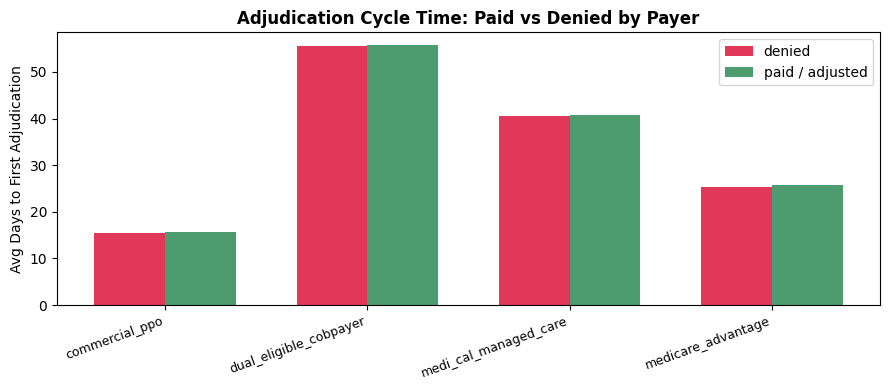

              payer_id         outcome  claim_count  avg_cycle_days
        commercial_ppo          denied         1461            15.5
        commercial_ppo paid / adjusted         5974            15.7
dual_eligible_cobpayer          denied          711            55.5
dual_eligible_cobpayer paid / adjusted          521            55.7
 medi_cal_managed_care          denied         3338            40.5
 medi_cal_managed_care paid / adjusted         7998            40.7
    medicare_advantage          denied         1241            25.4
    medicare_advantage paid / adjusted         3756            25.7


In [11]:
paid_vs_denied = con.execute("""
    WITH claim_cycle AS (
        SELECT
            ch.claim_id,
            ch.payer_id,
            ch.submission_date,
            MIN(r.adjudication_date)                                              AS first_adjudication_date,
            MAX(CASE WHEN r.carc_code NOT IN ('CO-45', 'PR-1')
                          AND r.paid_amount = 0
                     THEN 1 ELSE 0 END)                                           AS has_denial
        FROM claim_header ch
        JOIN remittance_835 r ON ch.claim_id = r.claim_id
        WHERE ch.submission_date IS NOT NULL
          AND r.adjudication_date IS NOT NULL
        GROUP BY ch.claim_id, ch.payer_id, ch.submission_date
    )
    SELECT
        payer_id,
        CASE WHEN has_denial = 1 THEN 'denied' ELSE 'paid / adjusted' END         AS outcome,
        COUNT(*)                                                                   AS claim_count,
        ROUND(AVG(date_diff('day', submission_date, first_adjudication_date)), 1) AS avg_cycle_days
    FROM claim_cycle
    GROUP BY payer_id, outcome
    ORDER BY payer_id, outcome
""").df()

pivot_outcome = paid_vs_denied.pivot(
    index="payer_id", columns="outcome", values="avg_cycle_days"
).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(pivot_outcome))
width = 0.35
color_map = {"denied": "crimson", "paid / adjusted": "seagreen"}
for i, col in enumerate(pivot_outcome.columns):
    offset = (i - (len(pivot_outcome.columns) - 1) / 2) * width
    ax.bar(x + offset, pivot_outcome[col], width,
           label=col, color=color_map.get(col, "steelblue"), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(pivot_outcome.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Avg Days to First Adjudication")
ax.set_title("Adjudication Cycle Time: Paid vs Denied by Payer", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(paid_vs_denied.to_string(index=False))

---------
#### Chapter 4 - Authorization Pipeline Velocity

###### Question: When did auth arrive relative to the service date — proactive or retroactive?

###### Radiology (68% obtain rate) and Oncology (75%) are the hypothesis. Missing auth → CO-57 denial. But *late* auth — obtained after the service date — is a different failure mode: the workflow is running behind the care delivery process, not simply failing to engage it.

In [11]:
# KPI table about the Providers' obtain rate of authorization in time 
auth_pipeline = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        COUNT(ec.encounter_id)                                                                             AS total_encounters,
        SUM(CASE WHEN ec.prior_auth_required = TRUE THEN 1 ELSE 0 END)                                    AS auth_required,
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE THEN 1 ELSE 0 END)                                    AS auth_obtained,
        ROUND(100.0 * SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN ec.prior_auth_required = TRUE THEN 1 ELSE 0 END), 0), 1)             AS obtain_rate_pct,
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date > ec.date_of_service THEN 1 ELSE 0 END)                        AS late_auth_count,
        ROUND(100.0 * SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE
                               AND ec.auth_request_date > ec.date_of_service THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE THEN 1 ELSE 0 END), 0), 1)               AS late_auth_rate_pct
    FROM encounter_context ec
    JOIN provider p ON ec.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type
    ORDER BY obtain_rate_pct ASC
""").df()

print("Auth Pipeline Velocity by Provider Persona\n")
print(auth_pipeline.to_string(index=False))

Auth Pipeline Velocity by Provider Persona

          practice_name              persona_type  total_encounters  auth_required  auth_obtained  obtain_rate_pct  late_auth_count  late_auth_rate_pct
        Radiology Group           prior_auth_miss              4936         3174.0         2170.0             68.4            490.0                22.6
         Oncology Group medical_necessity_denials              4928         3442.0         2580.0             75.0            387.0                15.0
        Emergency Group             coding_errors              5020           11.0           10.0             90.9              0.0                 0.0
Internal Medicine Group       slow_charge_capture              5129            8.0            8.0            100.0              0.0                 0.0
Behavioral Health Group      credentialing_errors              4987            8.0            8.0            100.0              0.0                 0.0


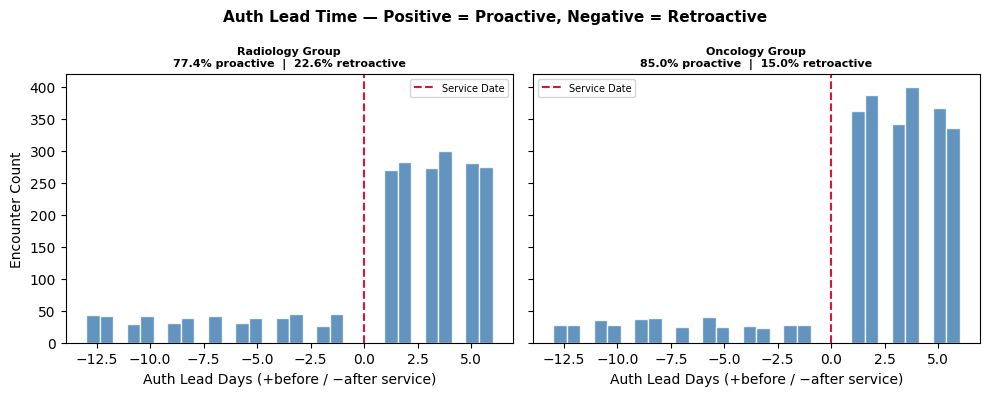

In [13]:
# Positive = auth arrived BEFORE service (proactive)
# Negative = auth arrived AFTER service (retroactive)
auth_timing = con.execute("""
    SELECT
        p.practice_name,
        date_diff('day', ec.auth_request_date, ec.date_of_service) AS auth_lead_days
    FROM encounter_context ec
    JOIN provider p ON ec.provider_id = p.provider_id
    WHERE ec.prior_auth_required = TRUE
      AND ec.prior_auth_obtained = TRUE
      AND ec.auth_request_date IS NOT NULL
      AND ec.date_of_service IS NOT NULL
""").df()

auth_providers = [
    prov for prov in auth_timing["practice_name"].unique()
    if auth_timing[auth_timing["practice_name"] == prov].shape[0] > 20
]

if not auth_providers:
    print("No providers with sufficient auth timing data (>20 records).")
    print("Check that auth_request_date is populated in encounter_context.")
else:
    fig, axes = plt.subplots(1, len(auth_providers),
                             figsize=(5 * len(auth_providers), 4), sharey=True)
    if len(auth_providers) == 1:
        axes = [axes]

    for ax, prov in zip(axes, auth_providers):
        subset = auth_timing[auth_timing["practice_name"] == prov]["auth_lead_days"]
        ax.hist(subset.clip(-30, 30), bins=30, edgecolor="white",
                color="steelblue", alpha=0.85)
        ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Service Date")
        late_pct = (subset < 0).mean() * 100
        proactive_pct = 100 - late_pct
        ax.set_title(
            f"{prov.replace('_', ' ')}\n"
            f"{proactive_pct:.1f}% proactive  |  {late_pct:.1f}% retroactive",
            fontsize=8, fontweight="bold"
        )
        ax.set_xlabel("Auth Lead Days (+before / −after service)")
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Encounter Count")
    fig.suptitle(
        "Auth Lead Time — Positive = Proactive, Negative = Retroactive",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()